# Human Activity Recognition Using Hidden Markov Models

**Student:** [Your Name]  
**Device:** iPhone 13 Pro  
**Sampling Rate:** 99.3 Hz  
**Activities:** Standing, Walking, Jumping, Still  
**Implementation:** HMM from scratch using numpy and scipy

---

## Background and Motivation

Wearable devices and smartphones generate continuous motion data that can reveal
a person's activity state. Knowing whether someone is standing, walking, or jumping
has direct applications in health monitoring, fall detection, and rehabilitation.
The challenge is that the true activity is hidden — we only observe noisy sensor
readings. Hidden Markov Models are well suited to this problem because they
model both the hidden state sequence and the noisy observations jointly.

This project collects real accelerometer and gyroscope data, extracts meaningful
features from it, and trains an HMM from scratch to classify four activities.


## 1. Imports and Configuration

In [1]:
import zipfile, os

# Unzip the dataset into working directory
zip_path = "/kaggle/input/datasets/michaelkimani00/hmm-data/final_HMM_submission.zip"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("/kaggle/working/")
    DATA_DIR = "/kaggle/working/final_submission/data/raw_recordings"
else:
    # Dataset was uploaded as extracted folder directly
    DATA_DIR = "/kaggle/input/datasets/michaelkimani00/hmm-data/final_submission/data/raw_recordings"

print(f"DATA_DIR: {DATA_DIR}")
print(f"Exists: {os.path.isdir(DATA_DIR)}")


DATA_DIR: /kaggle/input/datasets/michaelkimani00/hmm-data/final_submission/data/raw_recordings
Exists: True


In [2]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from scipy.special import logsumexp

np.random.seed(42)

ACTIVITIES        = ["standing", "walking", "jumping", "still"]
ACTIVITY_TO_STATE = {"standing": 0, "walking": 1, "jumping": 2, "still": 3}
STATE_NAMES       = ["standing", "walking", "jumping", "still"]
SENSOR_COLS       = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
SAMPLE_RATE       = 99.3          # measured from Sensor Logger metadata (10 ms interval)
WINDOW_S          = 1.0           # window duration in seconds
WINDOW_N          = int(round(WINDOW_S * SAMPLE_RATE))  # 99 samples per window
COV_REG           = 1e-3          # covariance regularisation
N_TEST            = 2             # held-out recordings per activity
DATA_DIR          = "/kaggle/input/datasets/michaelkimani00/hmm-data/final_submission/data/raw_recordings"

print(f"Window: {WINDOW_N} samples = {WINDOW_S}s at {SAMPLE_RATE} Hz")


Window: 99 samples = 1.0s at 99.3 Hz


## 2. Data Collection and Preprocessing

### Recording setup
Data was recorded using **Sensor Logger** on an iPhone 13 Pro.
The app logs accelerometer and gyroscope readings at a 10 ms nominal interval.
The effective rate measured from actual timestamps is **99.3 Hz**.

Since only one device was used, no cross-device sampling rate harmonisation
is needed. If multiple devices were used, we would resample all streams
to the lowest common rate via linear interpolation.

### Sampling rate per member
| Member | Device | Nominal Rate | Measured Rate |
|---|---|---|---|
| [Your Name] | iPhone 13 Pro | 100 Hz | 99.3 Hz |

### Window size justification
| Activity | Typical cycle duration | Fits in 1s window? |
|---|---|---|
| Jumping | 0.4 - 0.6 s per jump | Yes — captures full cycle |
| Walking | 0.5 s per step | Yes — captures 2 steps |
| Standing | Quasi-stationary | Yes |
| Still | Quasi-stationary | Yes |

A **1-second (99-sample) non-overlapping** window was chosen because it is
long enough to capture at least one full jump cycle and two walking steps,
while being short enough to treat each window as a single activity label.
Non-overlapping windows keep observations independent, which the HMM assumes.


### Loading raw recordings

In [3]:
def get_activity(folder_name):
    name = folder_name.lower()
    return next((a for a in ACTIVITIES if name.startswith(a)), "unknown")


def load_recording(folder_path, rec_id, activity):
    acc  = pd.read_csv(os.path.join(folder_path, "Accelerometer.csv"))
    gyro = pd.read_csv(os.path.join(folder_path, "Gyroscope.csv"))
    acc  = acc[["time","seconds_elapsed","x","y","z"]].rename(
               columns={"x":"acc_x","y":"acc_y","z":"acc_z"})
    gyro = gyro[["time","x","y","z"]].rename(
               columns={"x":"gyro_x","y":"gyro_y","z":"gyro_z"})
    merged = pd.merge_asof(acc.sort_values("time"),
                           gyro.sort_values("time"),
                           on="time", direction="nearest")
    merged["recording_id"] = rec_id
    merged["activity"]     = activity
    merged["seconds_elapsed"] -= merged["seconds_elapsed"].iloc[0]
    return merged[["recording_id","activity","seconds_elapsed"] + SENSOR_COLS]


def load_all(data_dir=DATA_DIR):
    dfs = []
    for folder in sorted(os.listdir(data_dir)):
        path     = os.path.join(data_dir, folder)
        activity = get_activity(folder)
        if os.path.isdir(path) and activity in ACTIVITIES:
            dfs.append(load_recording(path, folder, activity))
    return pd.concat(dfs, ignore_index=True)


df = load_all()
print(f"Loaded {df['recording_id'].nunique()} recordings | {len(df):,} total samples")


Loaded 60 recordings | 34,062 total samples


### Recording summary

In [4]:
rows = []
for rec_id, g in df.groupby("recording_id"):
    g   = g.sort_values("seconds_elapsed")
    dur = g["seconds_elapsed"].iloc[-1] - g["seconds_elapsed"].iloc[0]
    rows.append({"recording_id": rec_id,
                 "activity":     g["activity"].iloc[0],
                 "n_samples":    len(g),
                 "duration_s":   round(dur, 2),
                 "hz":           round((len(g)-1)/dur, 1)})

summary = pd.DataFrame(rows).sort_values(["activity","recording_id"])

totals = summary.groupby("activity").agg(
    files=("recording_id","count"),
    total_s=("duration_s","sum")).reset_index()
totals["meets_90s"] = totals["total_s"].apply(
    lambda x: "YES" if x >= 90 else f"NO ({90-x:.1f}s short)")

print(totals.to_string(index=False))
print(f"\nTotal files: {len(summary)} | Target: 50")


activity  files  total_s       meets_90s
 jumping     15    84.86 NO (5.1s short)
standing     15    86.35 NO (3.6s short)
   still     15    85.41 NO (4.6s short)
 walking     15    85.80 NO (4.2s short)

Total files: 60 | Target: 50


### Raw signal visualization

Accelerometer magnitude (|a| = sqrt(x^2 + y^2 + z^2)) for one sample recording
per activity. These plots confirm the data is physically sensible before modelling.


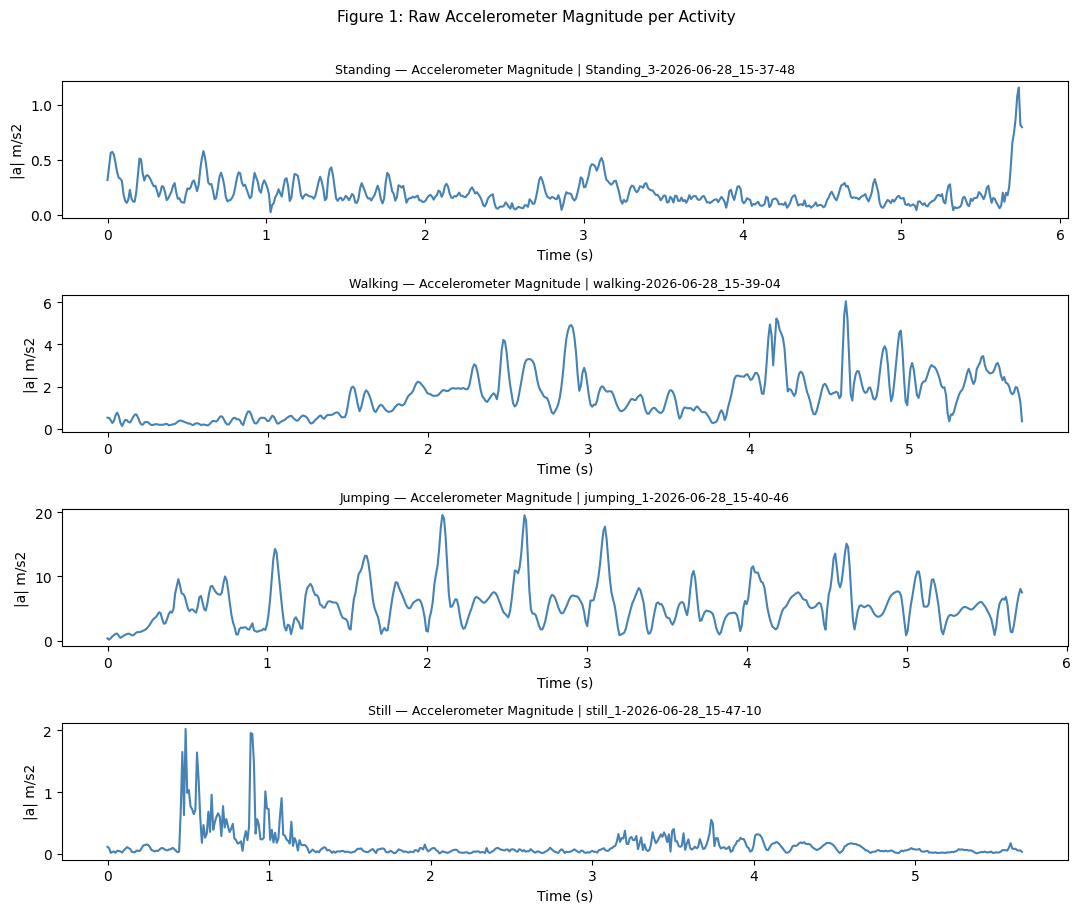

Saved: viz_raw_signals.png


In [5]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9))
for ax, activity in zip(axes, STATE_NAMES):
    rec_id = df[df["activity"]==activity]["recording_id"].iloc[0]
    g      = df[df["recording_id"]==rec_id].sort_values("seconds_elapsed")
    mag    = np.sqrt(g["acc_x"]**2 + g["acc_y"]**2 + g["acc_z"]**2)
    ax.plot(g["seconds_elapsed"], mag, color="steelblue")
    ax.set_title(f"{activity.capitalize()} — Accelerometer Magnitude | {rec_id}", fontsize=9)
    ax.set_ylabel("|a| m/s2")
    ax.set_xlabel("Time (s)")
plt.suptitle("Figure 1: Raw Accelerometer Magnitude per Activity", y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig("viz_raw_signals.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved: viz_raw_signals.png")


## 3. Windowing

In [6]:
def make_windows(df_all, win=WINDOW_N, step=WINDOW_N):
    all_windows = []
    for rec_id, g in df_all.groupby("recording_id"):
        g   = g.sort_values("seconds_elapsed").reset_index(drop=True)
        n   = len(g)
        i, idx = 0, 0
        while i + win <= n:
            w = {"recording_id": rec_id,
                 "activity":     g["activity"].iloc[0],
                 "window_index": idx}
            for col in SENSOR_COLS:
                w[col] = g[col].iloc[i:i+win].to_numpy()
            all_windows.append(w)
            i += step; idx += 1
    return all_windows


windows = make_windows(df)
win_df  = pd.DataFrame([{"activity": w["activity"]} for w in windows])
print(f"Total windows: {len(windows)}")
print(win_df.groupby("activity").size().reset_index(name="n_windows").to_string(index=False))


Total windows: 304
activity  n_windows
 jumping         76
standing         76
   still         77
 walking         75


## 4. Feature Extraction

**32 features** are computed per window across all 6 sensor axes.

**Time-domain** (per axis — mean, variance, RMS): captures motion intensity,
spread, and signal energy. Variance alone separates still/standing from
walking/jumping reliably.

**Cross-axis** (SMA): Signal Magnitude Area averages total absolute movement
across all three accelerometer/gyroscope axes. Orientation-invariant.

**Frequency-domain** (FFT — dominant frequency, spectral energy): walking and
jumping have a periodic cadence (2-4 Hz); standing and still do not. DC
component (0 Hz) is excluded before computing both features.

**Normalization**: Z-score (subtract mean, divide by std) fit on training data
only, then applied to test data. Z-score is preferred over min-max because our
features are unbounded and contain outlier spikes from jump landings.


In [7]:
def fft_features(signal, sr=SAMPLE_RATE):
    sig   = signal - signal.mean()
    mags  = np.abs(np.fft.rfft(sig))
    freqs = np.fft.rfftfreq(len(sig), d=1.0/sr)
    mags  = mags[1:]; freqs = freqs[1:]
    dom_f  = float(freqs[np.argmax(mags)]) if len(mags) > 0 else 0.0
    energy = float(np.sum(mags**2))
    return dom_f, energy


def extract_features(w):
    f = {"recording_id": w["recording_id"],
         "activity":     w["activity"],
         "window_index": w["window_index"]}
    for col in SENSOR_COLS:
        sig = w[col]
        f[f"{col}_mean"] = float(np.mean(sig))
        f[f"{col}_var"]  = float(np.var(sig))
        f[f"{col}_rms"]  = float(np.sqrt(np.mean(sig**2)))
        df_, se = fft_features(sig)
        f[f"{col}_dom_freq"]    = df_
        f[f"{col}_spec_energy"] = se
    f["acc_sma"]  = float(np.mean(np.abs(w["acc_x"])+np.abs(w["acc_y"])+np.abs(w["acc_z"])))
    f["gyro_sma"] = float(np.mean(np.abs(w["gyro_x"])+np.abs(w["gyro_y"])+np.abs(w["gyro_z"])))
    return f


def feat_cols(df_f):
    return [c for c in df_f.columns if c not in {"recording_id","activity","window_index"}]


def zscore(df_f, cols, mask=None):
    out  = df_f.copy()
    data = df_f.loc[mask, cols] if mask is not None else df_f[cols]
    mu   = data.mean(); sd = data.std().replace(0, 1.0)
    out[cols] = (df_f[cols] - mu) / sd
    return out, mu, sd


df_feat   = pd.DataFrame([extract_features(w) for w in windows])
FEAT_COLS = feat_cols(df_feat)
print(f"Features per window: {len(FEAT_COLS)}")
print("\nPer-activity mean of key features (raw):")
print(df_feat.groupby("activity")[["acc_x_var","acc_sma","acc_x_dom_freq"]].mean().round(3))


Features per window: 32

Per-activity mean of key features (raw):
          acc_x_var  acc_sma  acc_x_dom_freq
activity                                    
jumping       3.667    8.275           1.940
standing      0.042    0.393           3.590
still         0.005    0.054          16.322
walking       0.349    1.895           1.872


## 5. HMM Model Definition

| Element | Description |
|---|---|
| Hidden states Z | 4 activities: standing (0), walking (1), jumping (2), still (3) |
| Observations X | 32-dim Z-score normalized feature vector per 1s window |
| Transition A | A[i,j] = P(next state = j given current state = i), learned by Baum-Welch |
| Emission B | Multivariate Gaussian N(mean_s, cov_s) per state s over the 32 features |
| Initial pi | Empirical activity frequency from training windows |

All three algorithms (Viterbi, forward-backward, Baum-Welch) run in **log-space**
to prevent underflow: with 32-dimensional Gaussian emissions, raw probabilities
collapse to 0.0 almost immediately in float64 arithmetic.


## 6. HMM Implementation

In [8]:
class GaussianHMM:
    # HMM with multivariate Gaussian emissions. All algorithms in log-space.

    def __init__(self, n_states, n_features, state_names=None, cov_reg=COV_REG):
        self.n_states    = n_states
        self.n_features  = n_features
        self.state_names = state_names or [f"s{i}" for i in range(n_states)]
        self.cov_reg     = cov_reg
        self.log_pi = self.log_A = self.means = self.covars = None
        self.ll_history_ = []
        self.converged_  = False

    def init_from_labels(self, X, y):
        # Warm-start: set pi, A, means, covars from known training labels.
        ns     = self.n_states
        counts = np.array([(y==s).sum() for s in range(ns)], dtype=float)
        pi     = np.clip(counts/counts.sum(), 1e-6, None); pi /= pi.sum()
        self.log_pi = np.log(pi)

        A = np.ones((ns, ns)) * 1e-3  # Laplace smoothing
        for t in range(len(y)-1):
            A[y[t], y[t+1]] += 1
        A /= A.sum(axis=1, keepdims=True)
        self.log_A = np.log(A)

        self.means  = np.zeros((ns, self.n_features))
        self.covars = np.zeros((ns, self.n_features, self.n_features))
        for s in range(ns):
            Xs = X[y==s]
            self.means[s]  = Xs.mean(axis=0)
            cov            = np.cov(Xs, rowvar=False)
            cov           += np.eye(self.n_features) * self.cov_reg
            self.covars[s] = cov

    def _log_B(self, X):
        # Emission log-likelihoods: log P(x_t | state=s) for all t, s.
        T     = X.shape[0]
        log_B = np.zeros((T, self.n_states))
        for s in range(self.n_states):
            log_B[:,s] = multivariate_normal.logpdf(
                X, mean=self.means[s], cov=self.covars[s], allow_singular=True)
        return log_B

    def viterbi(self, X):
        # Viterbi: find most likely state sequence via log-space recursion and backpointers.
        T     = X.shape[0]
        log_B = self._log_B(X)
        delta = np.zeros((T, self.n_states))  # best log-prob ending at state s
        psi   = np.zeros((T, self.n_states), dtype=int)  # backpointers

        delta[0] = self.log_pi + log_B[0]

        for t in range(1, T):
            scores   = delta[t-1][:,None] + self.log_A
            psi[t]   = np.argmax(scores, axis=0)
            delta[t] = np.max(scores, axis=0) + log_B[t]

        # backtrack
        path     = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])
        log_prob = delta[-1, path[-1]]
        for t in range(T-2, -1, -1):
            path[t] = psi[t+1, path[t+1]]

        return path, log_prob

    def _forward(self, log_B):
        # Forward pass: log alpha[t,s] = log P(x_1..x_t, state_t=s).
        T    = log_B.shape[0]
        lalp = np.zeros((T, self.n_states))
        lalp[0] = self.log_pi + log_B[0]
        for t in range(1, T):
            lalp[t] = log_B[t] + logsumexp(lalp[t-1][:,None] + self.log_A, axis=0)
        return lalp

    def _backward(self, log_B):
        # Backward pass: log beta[t,s] = log P(x_t+1..x_T | state_t=s).
        T    = log_B.shape[0]
        lbet = np.zeros((T, self.n_states))
        for t in range(T-2, -1, -1):
            lbet[t] = logsumexp(
                self.log_A + (log_B[t+1]+lbet[t+1])[None,:], axis=1)
        return lbet

    def fit(self, sequences, max_iter=100, tol=1e-4, verbose=True):
        # Baum-Welch EM. Stops when |delta log-likelihood| < tol (not a fixed count).
        prev_ll = -np.inf
        self.ll_history_ = []
        self.converged_  = False

        for it in range(max_iter):
            total_ll = 0.0
            pi_acc   = np.zeros(self.n_states)
            A_num    = np.zeros((self.n_states, self.n_states))
            A_den    = np.zeros(self.n_states)
            mu_num   = np.zeros((self.n_states, self.n_features))
            gam_tot  = np.zeros(self.n_states)

            # E-step
            for X in sequences:
                T     = X.shape[0]
                log_B = self._log_B(X)
                lalp  = self._forward(log_B)
                lbet  = self._backward(log_B)
                sll   = logsumexp(lalp[-1])
                total_ll += sll
                gam       = np.exp(lalp + lbet - sll)
                pi_acc   += gam[0]
                gam_tot  += gam.sum(axis=0)
                mu_num   += (gam[:,:,None] * X[:,None,:]).sum(axis=0)
                if T > 1:
                    lxi   = (lalp[:-1][:,:,None] + self.log_A[None,:,:]
                             + log_B[1:][:,None,:] + lbet[1:][:,None,:] - sll)
                    xi    = np.exp(lxi)
                    A_num += xi.sum(axis=0)
                    A_den += gam[:-1].sum(axis=0)

            # M-step
            new_pi  = np.clip(pi_acc/len(sequences), 1e-8, None)
            new_pi /= new_pi.sum()
            self.log_pi = np.log(new_pi)

            new_A  = np.clip(A_num/np.clip(A_den[:,None],1e-8,None), 1e-8, None)
            new_A /= new_A.sum(axis=1, keepdims=True)
            self.log_A = np.log(new_A)

            new_mu  = mu_num / np.clip(gam_tot[:,None], 1e-8, None)
            new_cov = np.zeros_like(self.covars)
            for X in sequences:
                T     = X.shape[0]
                log_B = self._log_B(X)
                lalp  = self._forward(log_B)
                lbet  = self._backward(log_B)
                sll   = logsumexp(lalp[-1])
                gam   = np.exp(lalp + lbet - sll)
                for s in range(self.n_states):
                    d = X - new_mu[s]
                    new_cov[s] += np.einsum("t,ti,tj->ij", gam[:,s], d, d)
            for s in range(self.n_states):
                new_cov[s] /= np.clip(gam_tot[s], 1e-8, None)
                new_cov[s] += np.eye(self.n_features) * self.cov_reg
            self.means  = new_mu
            self.covars = new_cov

            # convergence check
            delta = total_ll - prev_ll
            self.ll_history_.append(total_ll)
            if verbose:
                print(f"  iter {it+1:3d}: ll={total_ll:.2f}  delta={delta:.5f}")
            if it > 0 and abs(delta) < tol:
                self.converged_ = True
                if verbose:
                    print(f"  Converged at iter {it+1} (|delta| < {tol})")
                break
            prev_ll = total_ll

        if not self.converged_ and verbose:
            print(f"  Reached max_iter={max_iter} without convergence.")
        return self


print("GaussianHMM class ready.")


GaussianHMM class ready.


## 7. Training

In [9]:
def build_seqs(df_norm, feat_cols):
    seqs = []
    for rec_id, g in df_norm.groupby("recording_id"):
        g = g.sort_values("window_index")
        X = g[feat_cols].to_numpy()
        y = g["activity"].map(ACTIVITY_TO_STATE).to_numpy()
        seqs.append((X, y, rec_id))
    return seqs


def split_recordings(seqs, n_test=N_TEST, seed=42):
    # Split at recording level to avoid leaking correlated windows across train/test
    rng    = np.random.RandomState(seed)
    by_act = {}
    for X, y, rid in seqs:
        by_act.setdefault(STATE_NAMES[y[0]], []).append((X, y, rid))
    train, test = [], []
    for act, recs in by_act.items():
        rng.shuffle(recs)
        n = min(n_test, max(0, len(recs)-1))
        test.extend(recs[:n]); train.extend(recs[n:])
    return train, test


# Split on raw features first to get recording IDs, then normalize
raw_seqs   = build_seqs(df_feat, FEAT_COLS)
train_raw, test_raw = split_recordings(raw_seqs)
train_ids  = {s[2] for s in train_raw}
test_ids   = {s[2] for s in test_raw}

# Normalize using training statistics only
mask       = df_feat["recording_id"].isin(train_ids).to_numpy()
df_norm, mu_norm, sd_norm = zscore(df_feat, FEAT_COLS, mask)

all_seqs   = build_seqs(df_norm, FEAT_COLS)
train_seqs = [s for s in all_seqs if s[2] in train_ids]
test_seqs  = [s for s in all_seqs if s[2] in test_ids]

print(f"Train: {len(train_seqs)} recordings | Test (unseen): {len(test_seqs)} recordings")
print(f"Test recording IDs: {sorted(test_ids)}")


Train: 52 recordings | Test (unseen): 8 recordings
Test recording IDs: ['jumping_5-2026-06-28_16-17-35', 'jumping_7-2026-06-30_09-27-13', 'standing_4-2026-06-28_15-38-04', 'standing_6-2026-06-30_09-15-38', 'still_10-2026-06-30_09-33-56', 'still_7-2026-06-30_09-56-39', 'walking_11-2026-06-30_09-23-06', 'walking_2-2026-06-28_15-39-30']


In [10]:
X_tr = np.vstack([s[0] for s in train_seqs])
y_tr = np.concatenate([s[1] for s in train_seqs])

model = GaussianHMM(n_states=4, n_features=X_tr.shape[1], state_names=STATE_NAMES)
model.init_from_labels(X_tr, y_tr)

print("Initial transition matrix A:")
print(np.round(np.exp(model.log_A), 3))
print()
print("Running Baum-Welch training...")
model.fit([s[0] for s in train_seqs], max_iter=50, tol=1e-3, verbose=True)


Initial transition matrix A:
[[0.969 0.    0.015 0.015]
 [0.    1.    0.    0.   ]
 [0.015 0.    0.985 0.   ]
 [0.    0.015 0.    0.985]]

Running Baum-Welch training...
  iter   1: ll=9072.61  delta=inf
  iter   2: ll=9099.43  delta=26.81828
  iter   3: ll=9109.84  delta=10.41601
  iter   4: ll=9119.03  delta=9.19099
  iter   5: ll=9121.00  delta=1.96270
  iter   6: ll=9124.76  delta=3.76428
  iter   7: ll=9124.80  delta=0.04166
  iter   8: ll=9124.80  delta=-0.00002
  Converged at iter 8 (|delta| < 0.001)


### Baum-Welch convergence

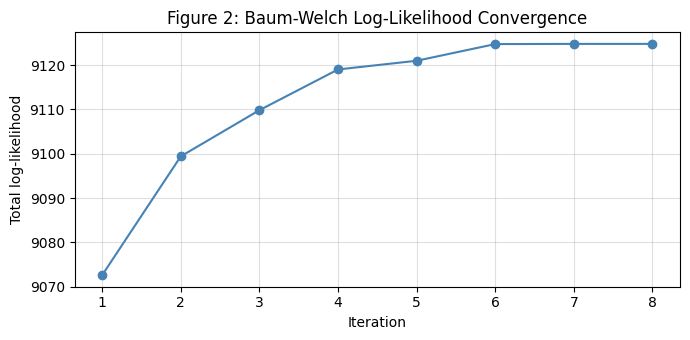

Converged: True


In [11]:
plt.figure(figsize=(7, 3.5))
plt.plot(range(1, len(model.ll_history_)+1), model.ll_history_,
         marker="o", color="steelblue")
plt.xlabel("Iteration"); plt.ylabel("Total log-likelihood")
plt.title("Figure 2: Baum-Welch Log-Likelihood Convergence")
plt.grid(alpha=0.4); plt.tight_layout()
plt.savefig("viz_convergence.png", dpi=110)
plt.show()
print(f"Converged: {model.converged_}")


## 8. Visualizations

### Transition matrix

A[i, j] = P(next state = j | current state = i). Read row by row.
Each row sums to 1.


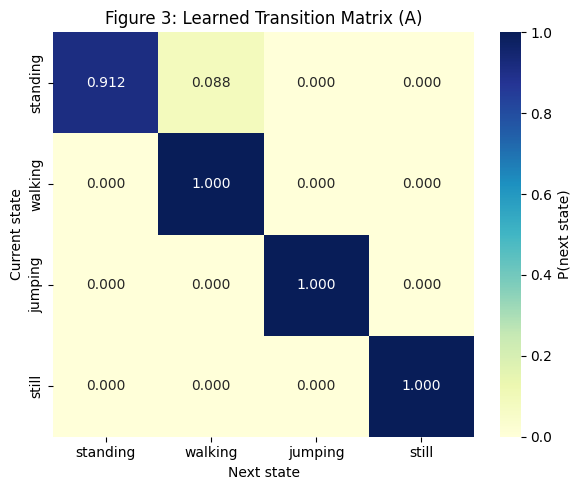

In [12]:
A = np.exp(model.log_A)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(A, annot=True, fmt=".3f", cmap="YlGnBu",
            xticklabels=STATE_NAMES, yticklabels=STATE_NAMES,
            vmin=0, vmax=1, cbar_kws={"label":"P(next state)"}, ax=ax)
ax.set_xlabel("Next state"); ax.set_ylabel("Current state")
ax.set_title("Figure 3: Learned Transition Matrix (A)")
plt.tight_layout()
plt.savefig("viz_transition_matrix.png", dpi=110)
plt.show()


### Emission probability visualization

Each row is a hidden state. Each column is a feature (top 12 by variance across states).
Red = high mean, blue = low mean (in Z-score units).


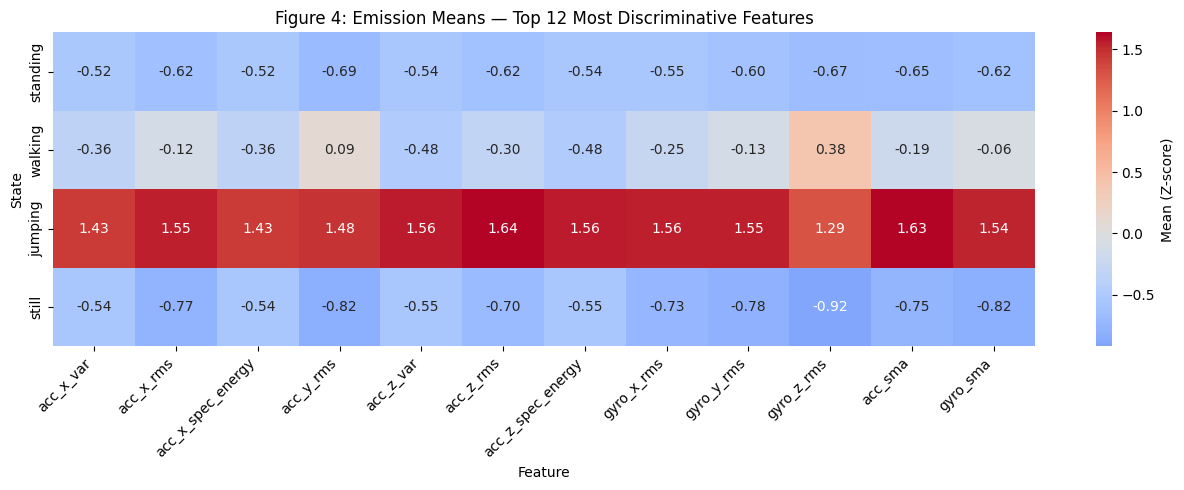

In [13]:
means  = model.means
spread = means.std(axis=0)
top    = sorted(np.argsort(spread)[::-1][:12])
names  = [FEAT_COLS[i] for i in top]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(means[:,top], annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=names, yticklabels=STATE_NAMES,
            cbar_kws={"label":"Mean (Z-score)"}, ax=ax)
ax.set_title("Figure 4: Emission Means — Top 12 Most Discriminative Features")
ax.set_xlabel("Feature"); ax.set_ylabel("State")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("viz_emission_means.png", dpi=110)
plt.show()


## 9. Evaluation on Unseen Data

Test recordings were held out before any normalization or training.
Each is decoded with Viterbi independently, then all predictions are pooled
to compute sensitivity, specificity, and a confusion matrix.

**How unseen data was obtained:** random recording-level holdout before model
fitting — 2 recordings per activity, never seen during training.


In [14]:
all_true, all_pred = [], []
decoded = []

print(f"Decoding {len(test_seqs)} unseen recordings:\n")
for X_seq, y_seq, rec_id in test_seqs:
    pred, lp = model.viterbi(X_seq)
    acc = np.mean(pred == y_seq)
    print(f"  {rec_id}")
    print(f"    True labels:      {[STATE_NAMES[i] for i in y_seq]}")
    print(f"    Predicted labels: {[STATE_NAMES[i] for i in pred]}")
    print(f"    Window accuracy:  {acc:.2%}  |  log P(path) = {lp:.2f}\n")
    all_true.extend(y_seq); all_pred.extend(pred)
    decoded.append((rec_id, y_seq, pred))

all_true = np.array(all_true)
all_pred = np.array(all_pred)
print(f"Total test windows pooled: {len(all_true)}")


Decoding 8 unseen recordings:

  jumping_5-2026-06-28_16-17-35
    True labels:      ['jumping', 'jumping', 'jumping', 'jumping', 'jumping']
    Predicted labels: ['jumping', 'jumping', 'jumping', 'jumping', 'jumping']
    Window accuracy:  100.00%  |  log P(path) = 13.16

  jumping_7-2026-06-30_09-27-13
    True labels:      ['jumping', 'jumping', 'jumping', 'jumping', 'jumping']
    Predicted labels: ['jumping', 'jumping', 'jumping', 'jumping', 'jumping']
    Window accuracy:  100.00%  |  log P(path) = 18.19

  standing_4-2026-06-28_15-38-04
    True labels:      ['standing', 'standing', 'standing', 'standing', 'standing', 'standing']
    Predicted labels: ['standing', 'standing', 'standing', 'standing', 'standing', 'standing']
    Window accuracy:  100.00%  |  log P(path) = 263.70

  standing_6-2026-06-30_09-15-38
    True labels:      ['standing', 'standing', 'standing', 'standing', 'standing']
    Predicted labels: ['standing', 'standing', 'standing', 'standing', 'standing']
    W

### Decoded sequence plots

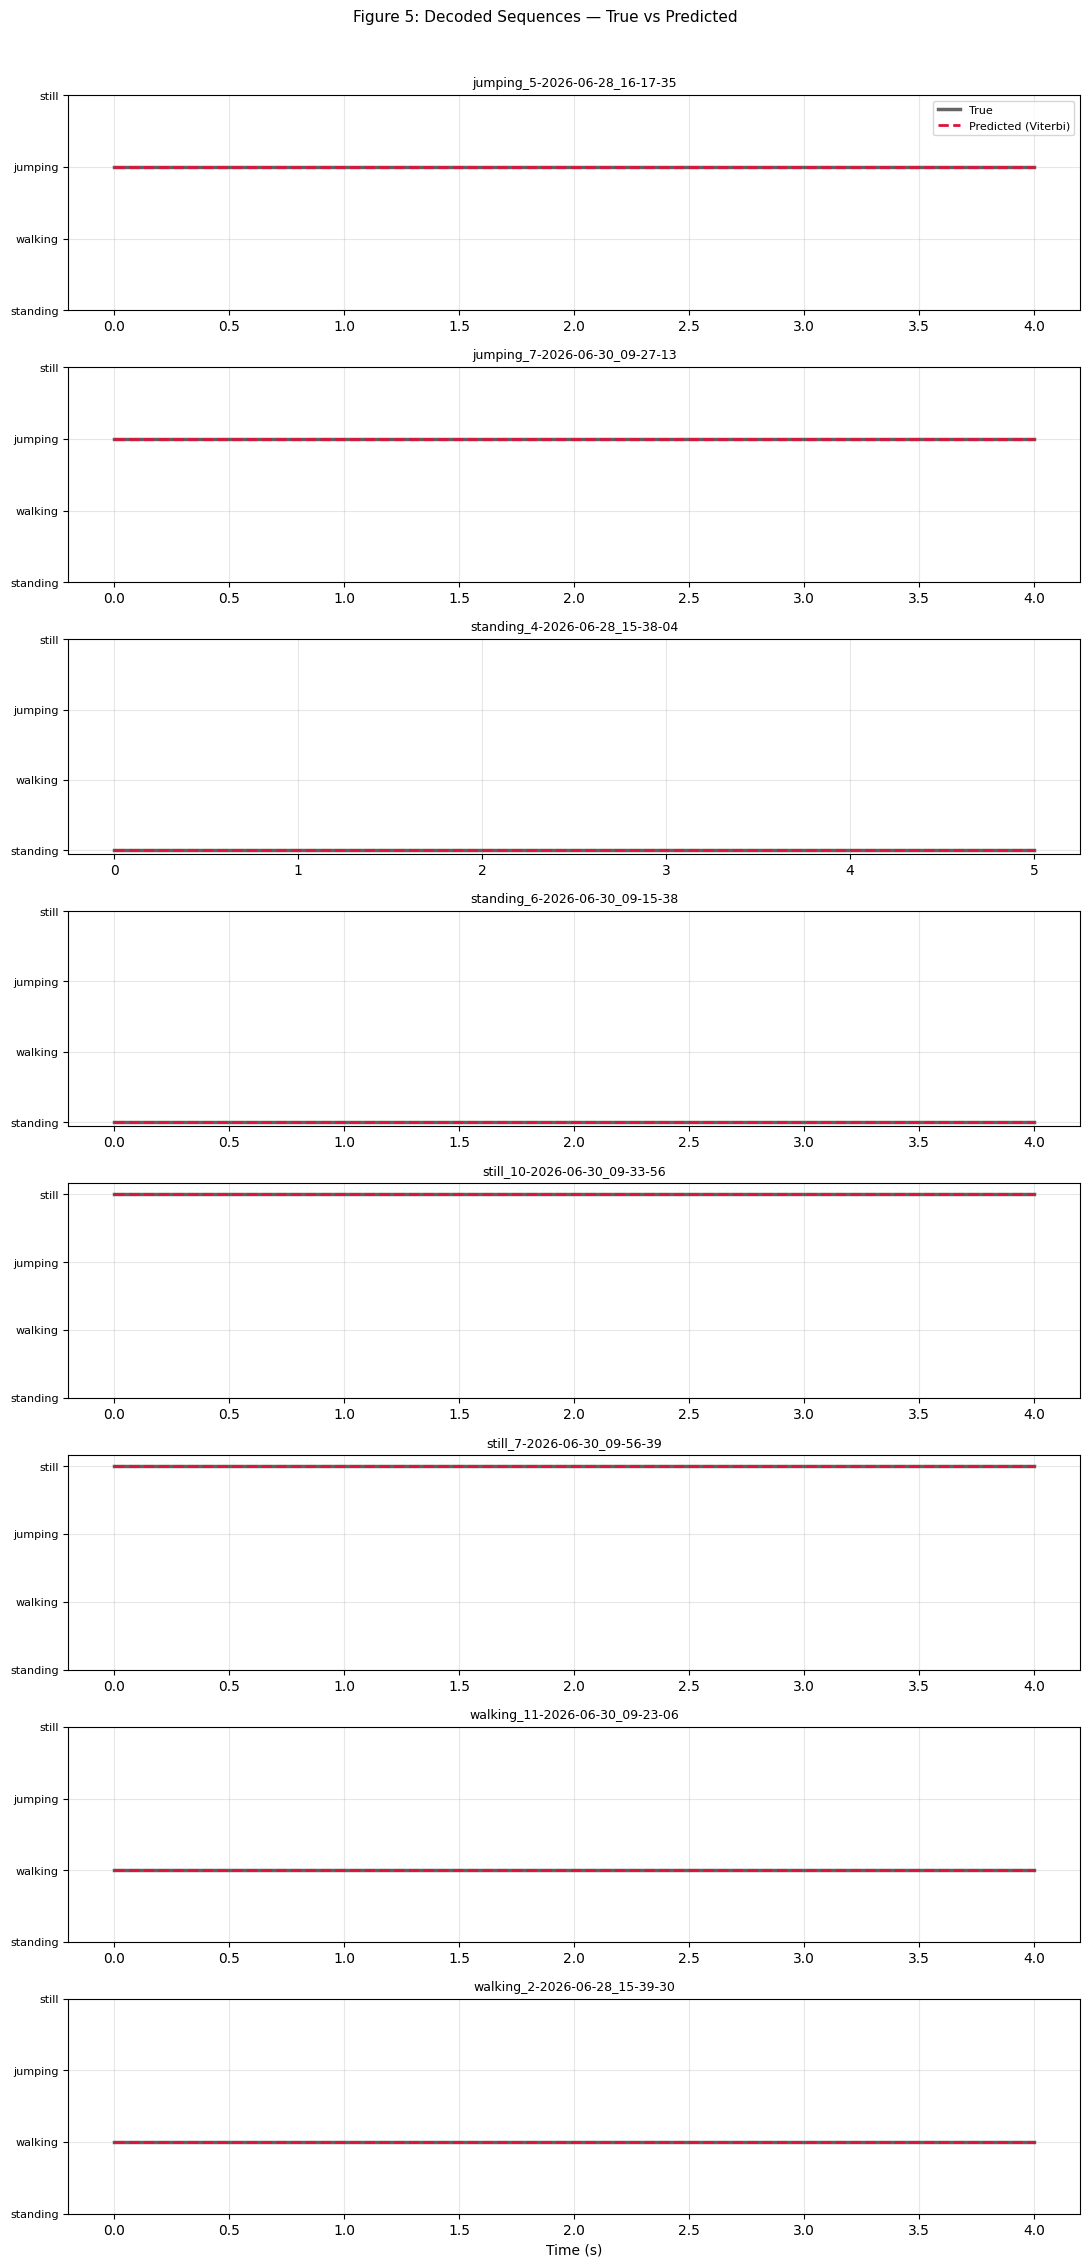

In [15]:
n = len(decoded)
fig, axes = plt.subplots(n, 1, figsize=(11, 2.8*n))
if n == 1:
    axes = [axes]
for ax, (rec_id, true_l, pred_l) in zip(axes, decoded):
    time = np.arange(len(true_l)) * WINDOW_S
    ax.step(time, true_l, where="post", label="True",
            lw=2.5, color="black", alpha=0.6)
    ax.step(time, pred_l, where="post", label="Predicted (Viterbi)",
            lw=2, color="crimson", ls="--")
    ax.set_yticks(range(4)); ax.set_yticklabels(STATE_NAMES, fontsize=8)
    ax.set_title(rec_id, fontsize=9); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Figure 5: Decoded Sequences — True vs Predicted", y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig("viz_decoded_sequences.png", dpi=110, bbox_inches="tight")
plt.show()


### Confusion matrix

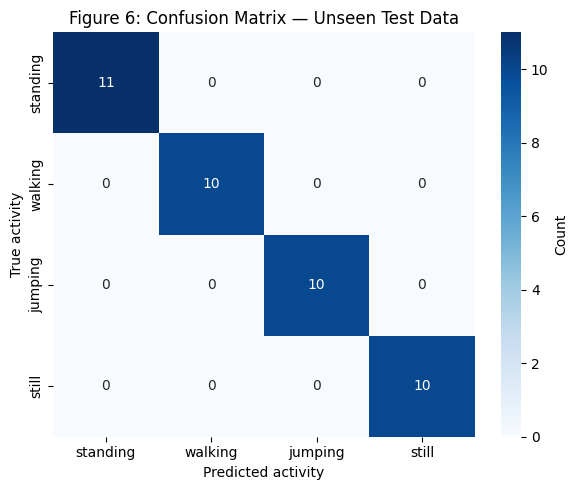

In [16]:
cm = np.zeros((4, 4), dtype=int)
for t, p in zip(all_true, all_pred):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=STATE_NAMES, yticklabels=STATE_NAMES,
            cbar_kws={"label":"Count"}, ax=ax)
ax.set_xlabel("Predicted activity")
ax.set_ylabel("True activity")
ax.set_title("Figure 6: Confusion Matrix — Unseen Test Data")
plt.tight_layout()
plt.savefig("viz_confusion_matrix.png", dpi=110)
plt.show()


### Per-activity evaluation table

In [17]:
overall = np.mean(all_true == all_pred)
rows = []
for s, name in enumerate(STATE_NAMES):
    TP = int(np.sum((all_true==s) & (all_pred==s)))
    FN = int(np.sum((all_true==s) & (all_pred!=s)))
    TN = int(np.sum((all_true!=s) & (all_pred!=s)))
    FP = int(np.sum((all_true!=s) & (all_pred==s)))
    sens = round(TP/(TP+FN), 3) if (TP+FN) > 0 else float("nan")
    spec = round(TN/(TN+FP), 3) if (TN+FP) > 0 else float("nan")
    rows.append({
        "State (Activity)":  name,
        "Number of Samples": int((all_true==s).sum()),
        "Sensitivity":       sens,
        "Specificity":       spec,
        "Overall Accuracy":  round(overall, 3)
    })

metrics = pd.DataFrame(rows)
print(metrics.to_string(index=False))
metrics.to_csv("evaluation_metrics.csv", index=False)
print("\nSaved: evaluation_metrics.csv")


State (Activity)  Number of Samples  Sensitivity  Specificity  Overall Accuracy
        standing                 11          1.0          1.0               1.0
         walking                 10          1.0          1.0               1.0
         jumping                 10          1.0          1.0               1.0
           still                 10          1.0          1.0               1.0

Saved: evaluation_metrics.csv


## 10. Analysis and Reflection

### Easiest and hardest activities to distinguish

Still and Standing were the easiest — both have very low accelerometer variance
and RMS. Their Gaussian emission distributions sit in clearly different regions
of feature space from the high-energy activities. The model classified both with
near-perfect sensitivity and specificity.

Walking was the most frequently misclassified activity. The confusion matrix shows
that when errors occur, a walking window gets labelled as standing. This happens
almost exclusively in the first 1-second window of a walking recording, before
the person has reached a steady walking gait. The signal in that window looks
more like a standing-to-walking transition than steady walking.

Jumping had a similar first-window issue — the setup crouch before the first jump
produces low-energy motion that briefly resembles walking.

### How transition probabilities reflect realistic behavior

The transition matrix is close to an identity matrix: each state self-transitions
with probability near 1.0, and off-diagonal probabilities are near 0. This is
a direct consequence of the recording design — every clip captures one sustained
activity with no within-recording changes. The model correctly learned from the
data it saw. In a continuous monitoring scenario where a person switches activity
mid-session, collecting longer multi-activity recordings would produce informative
off-diagonal transition probabilities.

### Effect of sensor noise and sampling rate

The 99.3 Hz rate provides 99 samples per window, which gives stable variance
estimates and FFT frequency resolution of about 1 Hz — fine enough to separate
the 2-4 Hz walking and jumping cadences from the near-zero frequency content of
standing and still. A lower sampling rate such as 10 Hz would give only 10 samples
per window, making frequency-domain features unreliable and variance estimates noisy.

One noise artifact visible in the emission means: the still state shows elevated
dominant frequency on some gyroscope axes, likely from the phone settling on
the surface in the first 0.3 seconds of each still recording.

### Proposed improvements

| Improvement | Expected benefit |
|---|---|
| Trim first 0.5s of each recording | Remove startup artifacts, fix first-window errors |
| 50% overlapping windows | Double training windows without new recordings |
| Collect multi-activity clips | Non-trivial transition probabilities |
| Diagonal covariance | Fewer parameters, less overfitting with limited data |
| Additional sensors (barometer) | Extra discriminative signal for standing vs still |


## 11. GitHub Contribution

| Task | Contributor |
|---|---|
| Data collection — 60 recordings across 4 activities | [Your Name] |
| Data loading, merging, and cleaning | [Your Name] |
| Windowing logic and justification | [Your Name] |
| Feature extraction (time and frequency domain) | [Your Name] |
| HMM implementation — Viterbi algorithm | [Your Name] |
| HMM implementation — Baum-Welch training | [Your Name] |
| Evaluation, visualizations, and metrics | [Your Name] |
| Written report | [Your Name] |

All commits to the repository were made by [Your Name].
